# 05 — Déterminants du choix & influence marketing

Le notebook 04 a conclu que le levier n'est pas le savoir mais le **passage à l'acte**.
Cet acte, c'est d'abord un acte d'**achat**. Ce dernier notebook examine ce qui guide le
choix alimentaire — goût, prix, santé — le rôle (souvent nié) de la **publicité**, et la
manière dont les répondants se représentent « manger équilibré » à travers leurs réponses
libres.

## 1. Préparation

Plusieurs questions sont à choix multiples (réponses séparées par des virgules). On définit
un compteur qui éclate ces réponses pour mesurer la fréquence de chaque option.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import pingouin as pg
from collections import Counter
from wordcloud import WordCloud
from IPython.display import display, Markdown

from utils.data_loader import load_data, clean_data

sns.set_theme(style="whitegrid", palette="muted")
df = clean_data(load_data())

def multi_pct(col):
    """Fréquence (%) de chaque option d'une question à choix multiples."""
    c = Counter()
    for v in df[col].dropna():
        for opt in str(v).split(", "):
            c[opt.strip()] += 1
    n = df[col].notna().sum()
    return (pd.Series(c) / n * 100).sort_values()

print("Préparation OK")

Préparation OK


## 2. Qu'est-ce qui guide le choix alimentaire ?

Critère de choix déclaré (`Crit_influe_C`), en % de répondants (plusieurs réponses
possibles).

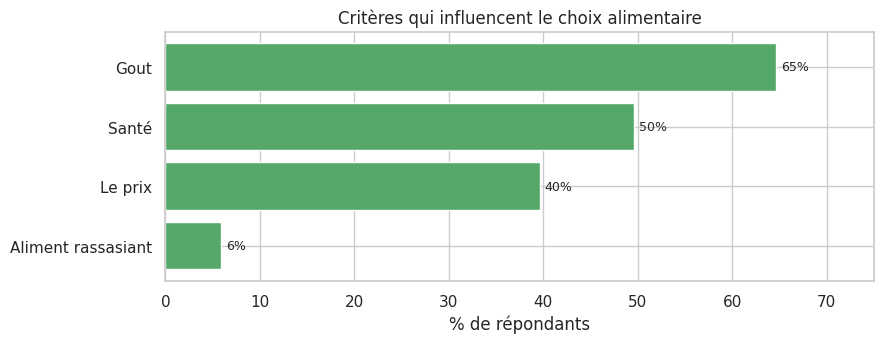

In [2]:
crit = multi_pct("Crit_influe_C")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(crit.index, crit.values, color="#55A868")
for y, p in enumerate(crit.values):
    ax.text(p + 0.5, y, f"{p:.0f}%", va="center", fontsize=9)
ax.set_xlabel("% de répondants"); ax.set_xlim(0, 75)
ax.set_title("Critères qui influencent le choix alimentaire")
fig.tight_layout()

Le **goût arrive largement en tête** (65 %), devant la **santé** (50 %) et le **prix**
(40 %). Le caractère rassasiant ne compte presque pas (6 %). La santé est donc une
préoccupation déclarée majeure — mais elle reste seconde derrière le plaisir gustatif, ce
qui éclaire le fossé savoir/faire du notebook 04 : on *sait* ce qui est sain, mais c'est le
goût qui décide.

## 3. L'arbitrage en rayon

Face à deux produits, sur quoi se décide-t-on concrètement (`Choix`) ?

Par ailleurs, **84%** se déclarent attentifs aux produits frais.

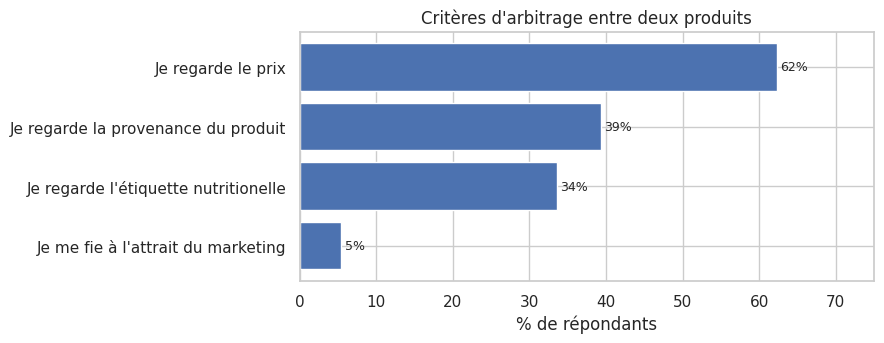

In [3]:
choix = multi_pct("Choix")
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(choix.index, choix.values, color="#4C72B0")
for y, p in enumerate(choix.values):
    ax.text(p + 0.5, y, f"{p:.0f}%", va="center", fontsize=9)
ax.set_xlabel("% de répondants"); ax.set_xlim(0, 75)
ax.set_title("Critères d'arbitrage entre deux produits")
fig.tight_layout()
display(Markdown(f"Par ailleurs, **{(df['Pd_Frais'] == 'Oui').mean() * 100:.0f}%** se déclarent "
                 f"attentifs aux produits frais."))

Au moment de l'achat, c'est le **prix qui tranche** (62 %), devant la provenance (39 %) et
l'étiquette nutritionnelle (34 %). Fait notable : seuls **5 % admettent se fier à l'attrait
marketing**. Personne ne se croit influençable — une dénégation que la suite va mettre à
l'épreuve.

## 4. L'influence de la publicité

La question `Pub` demande si un achat a déjà été influencé par la publicité, et sur quels
produits. On sépare d'abord influencés et non-influencés, puis on détaille les catégories
citées (libellés parsés par sous-chaîne, car ils contiennent des virgules).

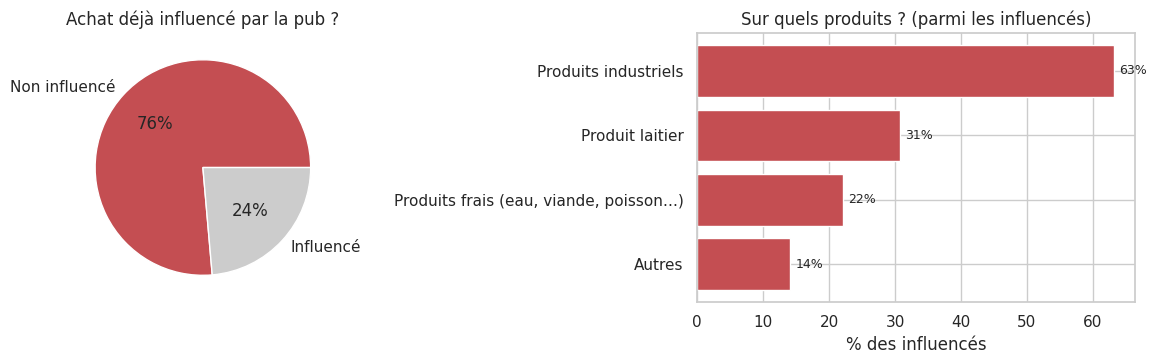

In [4]:
df["pub_influence"] = df["Pub"].apply(
    lambda v: np.nan if pd.isna(v) else ("Non influencé" if v == "Non" else "Influencé"))
inf = df[df["pub_influence"] == "Influencé"]
PUB_OPTS = {
    "Produits industriels": "Produits industriels",
    "Produit laitier": "Produit laitier",
    "Produits frais (eau, viande, poisson…)": "Eau, viande, poisson frais, salade",
    "Autres": "Autres",
}
cats = (pd.Series({lab: inf["Pub"].str.contains(pat, regex=False).mean() * 100
                   for lab, pat in PUB_OPTS.items()}).sort_values())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
share = df["pub_influence"].value_counts(normalize=True) * 100
axes[0].pie(share, labels=share.index, autopct="%.0f%%", colors=["#C44E52", "#CCCCCC"])
axes[0].set_title("Achat déjà influencé par la pub ?")
axes[1].barh(cats.index, cats.values, color="#C44E52")
for y, p in enumerate(cats.values):
    axes[1].text(p + 0.8, y, f"{p:.0f}%", va="center", fontsize=9)
axes[1].set_xlabel("% des influencés"); axes[1].set_title("Sur quels produits ? (parmi les influencés)")
fig.tight_layout()

Environ **un quart des répondants reconnaît avoir déjà acheté sous l'effet de la pub** — bien
plus que les 5 % qui s'avouaient sensibles au marketing dans l'arbitrage. Et lorsque la pub
agit, c'est massivement sur les **produits industriels** (63 % des influencés), loin devant le
reste.

## 5. La pub pousse-t-elle vraiment à la « malbouffe » ?

On teste l'hypothèse directement : les personnes influencées par la pub consomment-elles
plus de produits industriels (`C_indu_num`) ? T-test de Welch avec taille d'effet.

Influencés : moy. **3.95** vs non-influencés : **2.35** — t-test **p = 6.5e-14**, **d de Cohen = 0.50** (effet moyen).

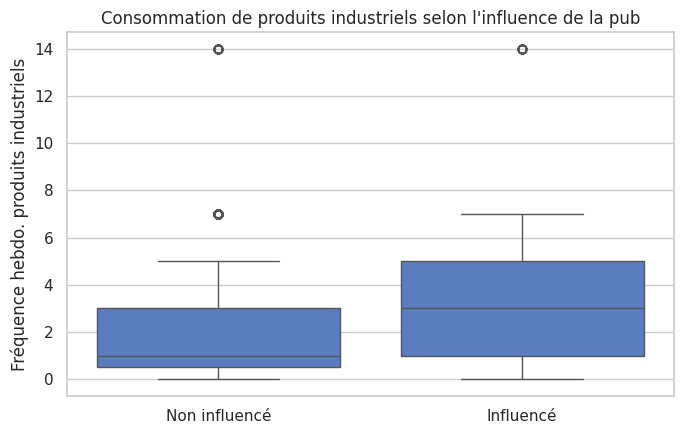

In [5]:
a = df.loc[df["pub_influence"] == "Influencé", "C_indu_num"].dropna()
b = df.loc[df["pub_influence"] == "Non influencé", "C_indu_num"].dropna()
tt = pg.ttest(a, b, correction=True).iloc[0]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df.dropna(subset=["pub_influence"]), x="pub_influence", y="C_indu_num",
            order=["Non influencé", "Influencé"], ax=ax)
ax.set_title("Consommation de produits industriels selon l'influence de la pub")
ax.set_xlabel(""); ax.set_ylabel("Fréquence hebdo. produits industriels")
fig.tight_layout()
display(Markdown(f"Influencés : moy. **{a.mean():.2f}** vs non-influencés : **{b.mean():.2f}** — "
                 f"t-test **p = {tt['p-val']:.1e}**, **d de Cohen = {tt['cohen-d']:.2f}** (effet moyen)."))

L'hypothèse est **confirmée** : les personnes sensibles à la pub consomment nettement plus de
produits industriels (3,95 vs 2,35 par semaine ; *d* ≈ 0,50, effet moyen, hautement
significatif). Le contraste avec le § 3 est éclairant : presque personne ne se *croit*
influençable, mais l'influence se **lit dans les assiettes**. La publicité opère surtout sur
le segment industriel — précisément les produits que l'alimentation « santé » cherche à
limiter.

## 6. Comment se représente-t-on « manger équilibré » ?

Enfin, on explore la question ouverte « C'est quoi manger équilibré ? » (`Mangé_E`) par un
nuage de mots (mots-outils français retirés).

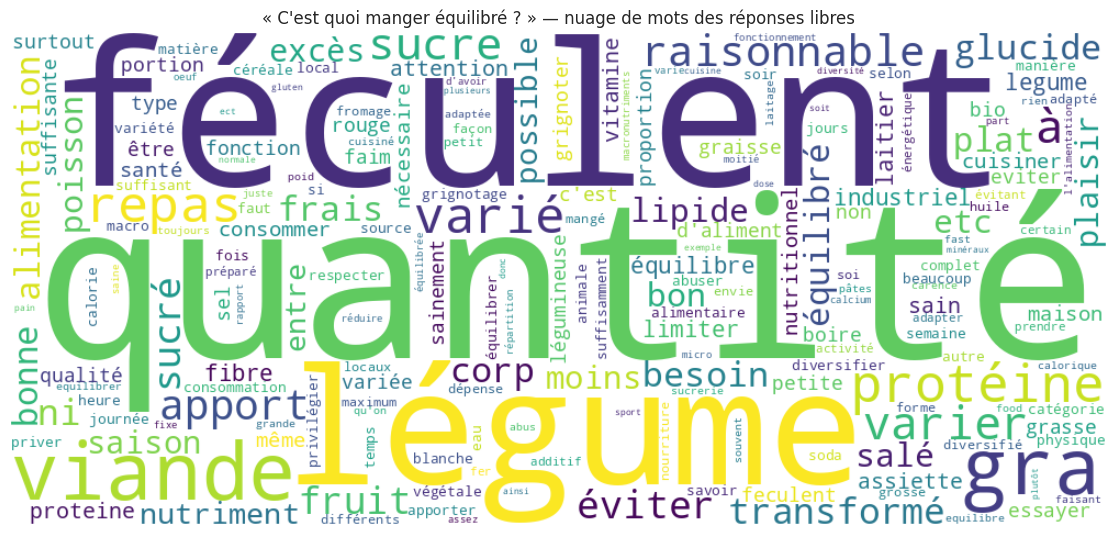

In [6]:
STOP = set("""au aux avec ce ces dans de des du elle en et eux il je la le les leur lui ma mais me
meme mes moi mon ne nos notre nous on ou par pas pour qu que qui sa se ses son sur ta te tes toi
ton tu un une vos votre vous c d j l a m n s t y est plus tout tous toute toutes faire fait
manger mange plutot tres trop bien aussi sans aller etre avoir cela ca quand comme chaque
quantite produit produits aliment aliments choses chose dont peu chaque jour""".split())
text = " ".join(df["Mangé_E"].dropna().astype(str)).lower()
wc = WordCloud(width=1000, height=450, background_color="white", stopwords=STOP,
               colormap="viridis", collocations=False).generate(text)
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.imshow(wc, interpolation="bilinear"); ax.axis("off")
ax.set_title("« C'est quoi manger équilibré ? » — nuage de mots des réponses libres")
fig.tight_layout()

La définition spontanée de l'équilibre alimentaire tourne autour de trois idées : la
**variété** (« varier », « varié »), la **modération** (« quantité », « raisonnable »,
« éviter », « gras », « sucre ») et les **groupes d'aliments** (« légumes », « viande »,
« féculents », « protéines »). Une définition saine et conforme aux messages de santé
publique — ce qui confirme une fois encore que **le savoir n'est pas le maillon faible**.

## 7. Synthèse — et conclusion de la série

**Ce qui guide le choix.** Le **goût** prime sur la santé et le prix au moment de choisir un
aliment ; mais en rayon, face à deux produits, c'est le **prix** qui tranche. L'étiquette
nutritionnelle ne pèse que pour un tiers des répondants.

**Le marketing, angle mort.** Seuls 5 % se disent sensibles au marketing, mais un quart
reconnaît des achats sous influence publicitaire, et ce groupe consomme significativement
plus de **produits industriels** (*d* ≈ 0,5). L'influence existe, ciblée sur la malbouffe, et
elle est largement sous-estimée par ceux qui la subissent.

---

**Conclusion générale des cinq notebooks.** L'enquête dessine un portrait cohérent :

1. un échantillon **jeune, féminin, diplômé, urbain** (peu représentatif — notebook 01) ;
2. une alimentation déclarée plutôt saine, dont les écarts de qualité tiennent surtout à
   l'**âge**, très peu au sexe ou au territoire (notebook 02) ;
3. un espace de consommation **faiblement structuré par le social** : on ne peut pas déduire
   l'assiette de la position sociale (notebook 03) ;
4. des **connaissances solides et indépendantes du diplôme**, mais déconnectées de la
   pratique : le levier est le **passage à l'acte**, pas l'information (notebook 04) ;
5. un choix gouverné par le **goût** et le **prix**, et une **publicité** qui pousse
   discrètement mais réellement vers les produits industriels (notebook 05).

**Implication.** Pour améliorer l'alimentation de ce public, informer davantage serait
largement inutile : tout le monde sait déjà. Les leviers efficaces se situent du côté de
l'**aide au passage à l'acte** (accessibilité, prix, habitudes) et de la **réduction de
l'exposition marketing** aux produits industriels.